# layer_3_xc：p4 / p4* 到达序列模拟

按修正后的逻辑逐步模拟单个神经元电位 v 的变化（从 S?/S0 的 0 出发）：

- **p4 到达**：`0_to_3` 作用 -1，电位变为 **-1**
- **p4* 第一步到达**：`2_to_3` first 再作用 -1；因为电位地板是 -1，所以**仍然是 -1**（被截断，不会掉到 -2）
- **p4* 第二步到达**：`2_to_3` second 再作用 +2，电位变为 **+1**

规则：每次权重作用后立即在地板处截断：`v = max(v + w, -1)`（threshold_low = -1）；一次到达处理完若 `v ≥ 2` 则发射并归零（本序列不会发射）。

In [1]:
# 1. 导入依赖与设置绘图样式
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# 2. 初始化 p4 / p4* 状态与历史记录
FLOOR = -1              # 电位地板（threshold_low）：任何一次作用后不低于 -1
W_P4 = -1               # p4 到达：0_to_3 在 +1 位的权重
W_P4_STAR_FIRST = -1    # p4* 第一步：2_to_3 first 在 +1 位的权重
W_P4_STAR_SECOND = +2   # p4* 第二步：2_to_3 second 在 +1 位的权重

def new_state():
    """初始状态：v 为膜电位；p4 / p4* 分别记录各自事件作用后的电位。"""
    return {"v": 0, "p4": 0, "p4_star": 0, "p4_star_arrival_count": 0, "history": []}

new_state()

{'v': 0, 'p4': 0, 'p4_star': 0, 'p4_star_arrival_count': 0, 'history': []}

In [3]:
# 3. 实现到达事件单步更新函数
def apply_arrival(state, event):
    """处理一次到达事件，更新电位；每次权重作用后在地板 FLOOR 处截断。

    event == "p4"  ：0_to_3 作用一次（-1）→ 电位 -1
    event == "p4*" ：第 1 次到达 = 2_to_3 第一步（-1）：被地板截断，仍是 -1；
                     第 2 次及以后到达 = 2_to_3 第二步（+2）→ 电位 +1
    """
    if event == "p4":
        state["v"] = max(state["v"] + W_P4, FLOOR)                    # 0_to_3
        state["p4"] = state["v"]
    elif event == "p4*":
        state["p4_star_arrival_count"] += 1
        if state["p4_star_arrival_count"] == 1:
            state["v"] = max(state["v"] + W_P4_STAR_FIRST, FLOOR)     # 2_to_3 第一步
        else:
            state["v"] = max(state["v"] + W_P4_STAR_SECOND, FLOOR)    # 2_to_3 第二步
        state["p4_star"] = state["v"]
    else:
        raise ValueError(f"未知事件: {event}")
    return state

In [4]:
# 4. 模拟到达序列并记录每步状态
def simulate_arrivals(events, initial_state=None):
    """按顺序依次调用 apply_arrival，并记录每一步的完整状态。

    返回 (最终状态, DataFrame)；表格列为：
    step、event、p4、p4_star、p4_star_arrival_count。
    """
    state = initial_state if initial_state is not None else new_state()
    for step, event in enumerate(events, start=1):
        apply_arrival(state, event)
        state["history"].append({
            "step": step,
            "event": event,
            "p4": state["p4"],
            "p4_star": state["p4_star"],
            "p4_star_arrival_count": state["p4_star_arrival_count"],
        })
    return state, pd.DataFrame(state["history"])

In [5]:
# 5. 运行示例到达序列：p4 到达 → p4* 第一步到达 → p4* 第二步到达
events = ["p4", "p4*", "p4*"]
final_state, df = simulate_arrivals(events)

print("到达序列:", events)
print(f"p4  最终值 = {final_state['p4']}   （p4 到达后应为 -1）")
print(f"p4* 最终值 = {final_state['p4_star']}   （第一步 -1 → 第二步 +1）")

到达序列: ['p4', 'p4*', 'p4*']
p4  最终值 = -1   （p4 到达后应为 -1）
p4* 最终值 = 1   （第一步 -1 → 第二步 +1）


In [6]:
# 6. 打印逐步状态表
df

,step,event,p4,p4_star,p4_star_arrival_count
0,1,p4,-1,0,0
1,2,p4*,-1,-1,1
2,3,p4*,-1,1,2


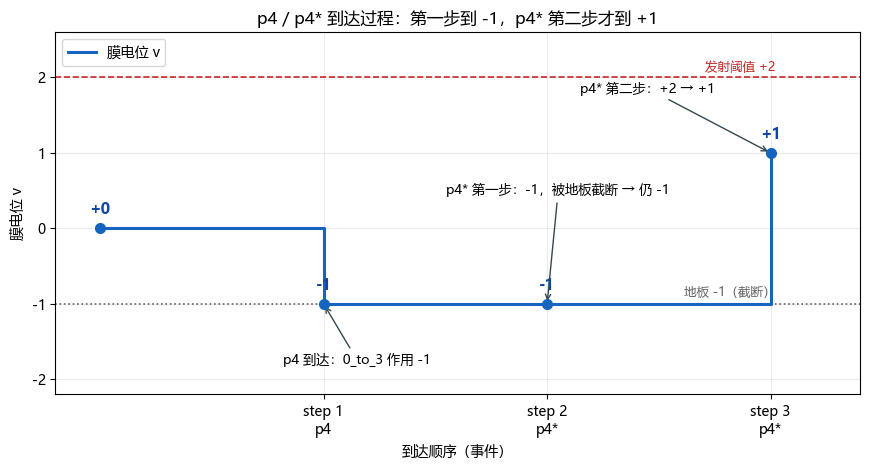

In [7]:
# 7. 可视化 p4 与 p4* 随到达步骤变化
# 电位序列：p4 事件后取 p4 列；p4* 事件后取 p4_star 列
v_values = [row["p4_star"] if "*" in row["event"] else row["p4"] for _, row in df.iterrows()]

xs = np.r_[0, df["step"].to_numpy()]
ys = np.r_[0, np.array(v_values, dtype=float)]

fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.step(xs, ys, where="post", color="#1565C0", lw=2.2, zorder=3, label="膜电位 v")
ax.plot(xs, ys, "o", color="#1565C0", ms=7, zorder=4)

# 参考线：地板 -1 与发射阈值 +2
ax.axhline(-1, color="#616161", ls=":", lw=1.2)
ax.text(3.02, -0.9, "地板 -1（截断）", color="#616161", fontsize=9, ha="right")
ax.axhline(2, color="#C62828", ls="--", lw=1.2)
ax.text(3.02, 2.08, "发射阈值 +2", color="#C62828", fontsize=9, ha="right")

# 数值标注
for x_, y_ in zip(xs, ys):
    ax.annotate(f"{y_:+.0f}", (x_, y_), xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=11, fontweight="bold", color="#0D47A1")

# 事件说明
ax.annotate("p4 到达：0_to_3 作用 -1", (1, -1), xytext=(1.15, -1.8),
            ha="center", fontsize=9.5, arrowprops=dict(arrowstyle="->", color="#37474F"))
ax.annotate("p4* 第一步：-1，被地板截断 → 仍 -1", (2, -1), xytext=(2.05, 0.45),
            ha="center", fontsize=9.5, arrowprops=dict(arrowstyle="->", color="#37474F"))
ax.annotate("p4* 第二步：+2 → +1", (3, 1), xytext=(2.45, 1.8),
            ha="center", fontsize=9.5, arrowprops=dict(arrowstyle="->", color="#37474F"))

ax.set_xticks(xs[1:], [f"step {int(s)}\n{e}" for s, e in zip(df["step"], df["event"])])
ax.set_xlim(-0.2, 3.4)
ax.set_ylim(-2.2, 2.6)
ax.set_xlabel("到达顺序（事件）")
ax.set_ylabel("膜电位 v")
ax.set_title("p4 / p4* 到达过程：第一步到 -1，p4* 第二步才到 +1")
ax.grid(alpha=0.25)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [8]:
# 8. 验证 p4* 两阶段到达逻辑
assert df.loc[0, "p4"] == -1, "p4 到达后应为 -1"
assert df.loc[1, "p4_star"] == -1, "p4* 第一次到达后应仍为 -1（被地板 -1 截断）"
assert df.loc[2, "p4_star"] == 1, "p4* 第二次到达后应为 +1"
assert df.loc[2, "p4_star_arrival_count"] == 2, "p4* 到达计数应为 2"

print("✔ 验证通过：")
print("   p4 到达        → 电位 -1")
print("   p4* 第一步到达 → 电位 -1（-1 再 -1，被地板截断）")
print("   p4* 第二步到达 → 电位 +1（-1 再 +2）")
print("✔ 本 notebook 为独立模拟，未写入或修改任何现有文件。")

✔ 验证通过：
   p4 到达        → 电位 -1
   p4* 第一步到达 → 电位 -1（-1 再 -1，被地板截断）
   p4* 第二步到达 → 电位 +1（-1 再 +2）
✔ 本 notebook 为独立模拟，未写入或修改任何现有文件。
